**Step 1: Install Required Libraries**

In [25]:
!pip install gdown matplotlib opencv-python numpy scipy --quiet

**Step 2: Download the Image**

In [26]:
import gdown
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Google Drive link to the image
image_url = 'https://drive.google.com/uc?id=1CPXI4SQSRRlq5HKJkW6_D5ezpxuN7B3R'
output_path = 'real_image.jpg'  # you can change the extension if it's jpg

# Download the image
gdown.download(image_url, output_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1CPXI4SQSRRlq5HKJkW6_D5ezpxuN7B3R
To: /content/real_image.jpg
100%|██████████| 92.6k/92.6k [00:00<00:00, 3.53MB/s]


'real_image.jpg'

**Step 3: Load and Display the Mosaic Image**

Image shape: (408, 612, 3)


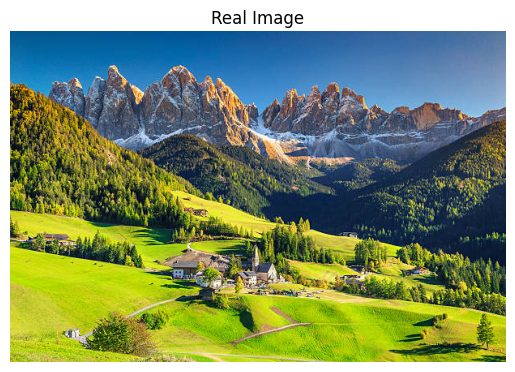

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Load the actual image
def load_real_image(path):
    img = Image.open(path)
    img = img.convert('RGB')  # ensure it's in RGB
    img_array = np.array(img)
    print(f"Image shape: {img_array.shape}")
    return img_array

real_image = load_real_image(output_path)

# Display the real image
plt.imshow(real_image)
plt.title('Real Image')
plt.axis('off')
plt.show()

**Step 4: Demosaicing Techniques**

**4.1 Bilinear Interpolation**

    Definition:
        # Bilinear interpolation estimates the value of a pixel by taking a weighted average
        # of the 4 nearest neighboring pixels in 2D. It is commonly used in image resizing
        # and demosaicing to fill in missing pixel values smoothly.
    
    Formula (for a pixel at (x, y) using neighbors (x1,y1),(x2,y2),(x3,y3),(x4,y4)):
        #   I(x,y) ≈ (1/4) * [ I(x1,y1) + I(x2,y2) + I(x3,y3) + I(x4,y4) ]
        # In our implementation, we use a smoothing kernel to mimic this averaging.

In [28]:
from scipy.ndimage import convolve, laplace
import numpy as np
import matplotlib.pyplot as plt

# Simplified Bilinear Interpolation (just a smoothing filter for demonstration)
def bilinear_interpolation(real_image):
    kernel = np.array([[1, 2, 1],
                       [2, 4, 2],
                       [1, 2, 1]], dtype=np.float32) / 16
    rgb_image = np.zeros_like(real_image)
    for i in range(3):
        rgb_image[:, :, i] = convolve(real_image[:, :, i], kernel, mode='reflect')
    return rgb_image

**4.2 Averaging Red and Blue Hues**

    Definition:
        # This method emphasizes averaging the red and blue channels to reduce artifacts
        # or noise in those channels. It smooths the pixel values by considering local neighbors.
    
    Formula:
        #   R_avg(x,y) = (1/8) * sum_{(i,j)∈neighbors} R(i,j)
        #   G_avg(x,y) = (1/8) * sum_{(i,j)∈neighbors} G(i,j)
        #   B_avg(x,y) = (1/8) * sum_{(i,j)∈neighbors} B(i,j)
            # where 'neighbors' refers to the 3x3 surrounding pixels.

In [29]:
# Average Red-Blue hues smoothing
def average_red_blue_hues(real_image):
    kernel = np.array([[0, 1, 0],
                       [1, 4, 1],
                       [0, 1, 0]], dtype=np.float32) / 8
    rgb_image = np.zeros_like(real_image)
    for i in range(3):
        rgb_image[:, :, i] = convolve(real_image[:, :, i], kernel, mode='reflect')
    return rgb_image

**4.3 Laplacian-Corrected Edge-Correlated Interpolation**

    Definition:
        # Laplacian-corrected interpolation enhances edges during interpolation
        # by adding the Laplacian (second derivative) of the image to the original image.
        This helps preserve high-frequency details while smoothing other areas.
    
    Formula:
        #   I_corrected(x,y) = I(x,y) + ∇²I(x,y)
          # where ∇²I(x,y) is the Laplacian of the image at pixel (x,y).

In [30]:
# Laplacian-corrected interpolation (edge enhancement)
def laplacian_corrected_interpolation(real_image):
    rgb_image = np.zeros_like(real_image)
    for i in range(3):
        lap = laplace(real_image[:, :, i])
        rgb_image[:, :, i] = np.clip(real_image[:, :, i] + lap, 0, 255)
    return rgb_image.astype(np.uint8)

# Apply operations
bilinear_rgb = bilinear_interpolation(real_image)
average_rgb = average_red_blue_hues(real_image)
laplacian_rgb = laplacian_corrected_interpolation(real_image)

**Step 5: Visualize the Results**

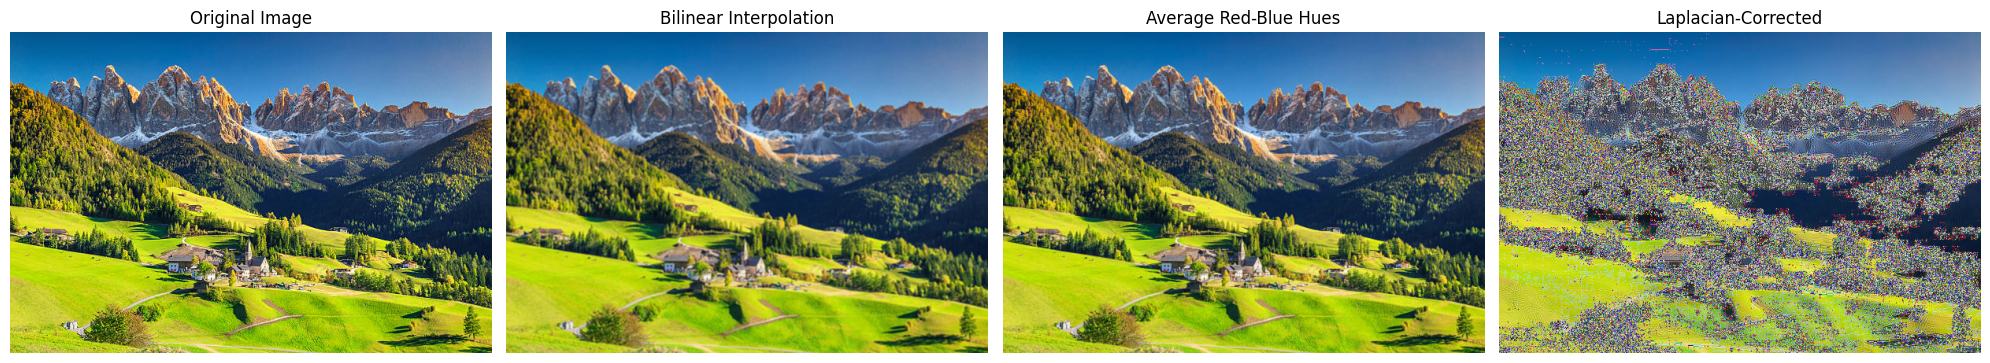

In [31]:
# Display the results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(real_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(bilinear_rgb)
axes[1].set_title('Bilinear Interpolation')
axes[1].axis('off')

axes[2].imshow(average_rgb)
axes[2].set_title('Average Red-Blue Hues')
axes[2].axis('off')

axes[3].imshow(laplacian_rgb)
axes[3].set_title('Laplacian-Corrected')
axes[3].axis('off')

plt.tight_layout()
plt.show()

Step 6: Plot Chromaticity Diagrams

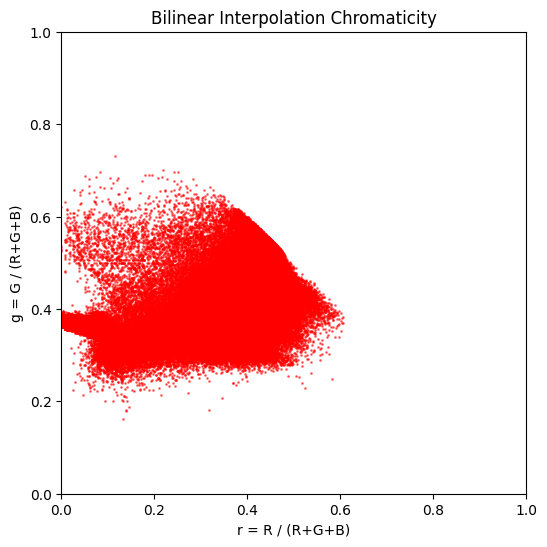

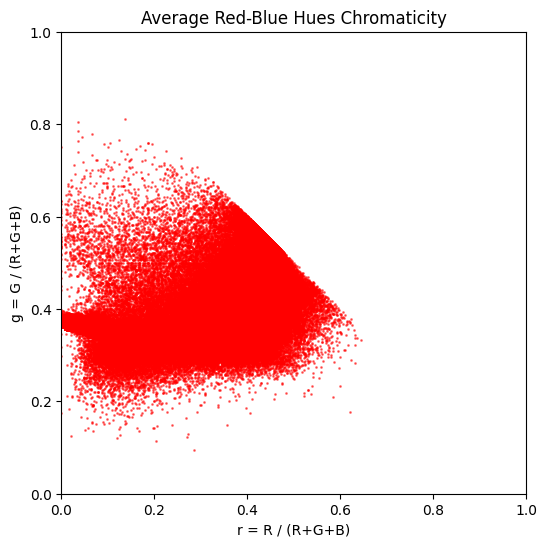

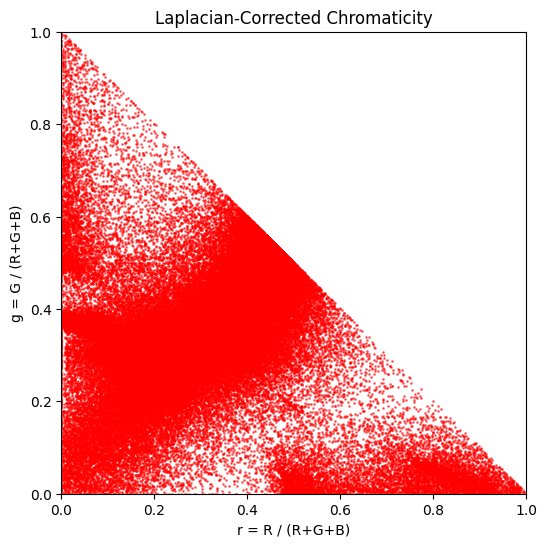

In [32]:
# Chromaticity diagrams remain the same
def plot_chromaticity(rgb_image, title='Chromaticity Diagram'):
    rgb_normalized = rgb_image / 255.0
    R, G, B = rgb_normalized[:, :, 0], rgb_normalized[:, :, 1], rgb_normalized[:, :, 2]
    sum_rgb = R + G + B + 1e-6  # prevent division by zero
    r = R / sum_rgb
    g = G / sum_rgb
    plt.figure(figsize=(6, 6))
    plt.scatter(r.flatten(), g.flatten(), color='red', s=1, alpha=0.5)
    plt.title(title)
    plt.xlabel('r = R / (R+G+B)')
    plt.ylabel('g = G / (R+G+B)')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

plot_chromaticity(bilinear_rgb, 'Bilinear Interpolation Chromaticity')
plot_chromaticity(average_rgb, 'Average Red-Blue Hues Chromaticity')
plot_chromaticity(laplacian_rgb, 'Laplacian-Corrected Chromaticity')

**Step 7: Compare Interpolation Techniques**

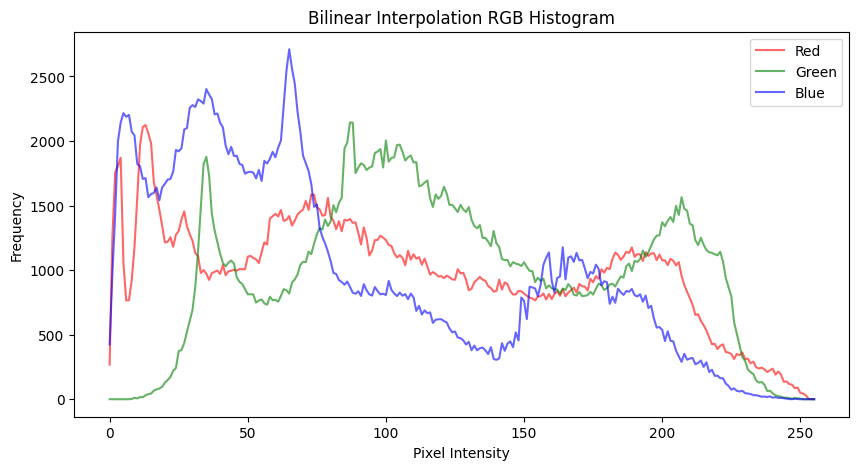

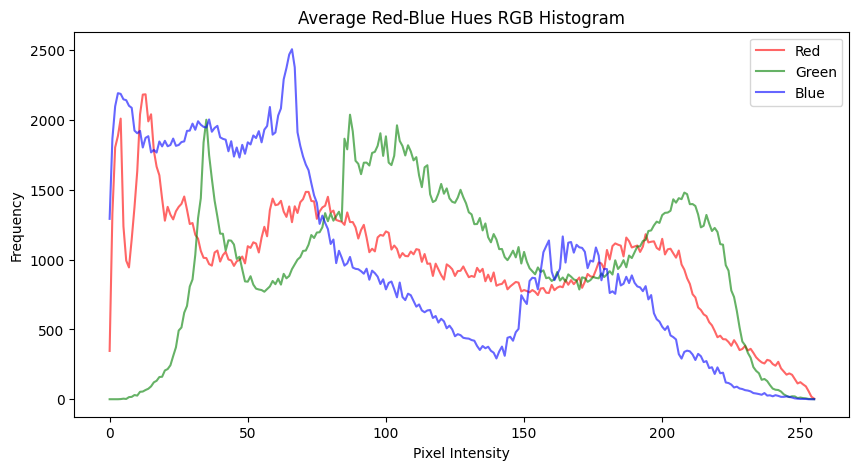

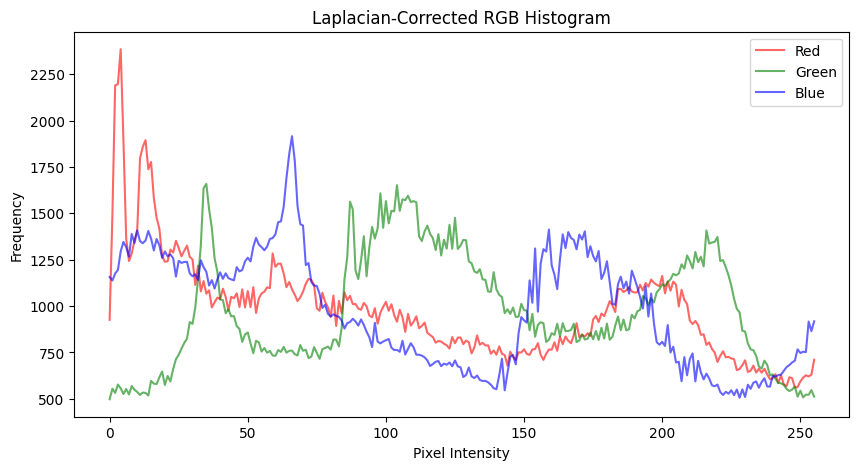

In [33]:
# RGB Histograms remain the same
def plot_histograms(rgb_image, title='RGB Histogram'):
    R, G, B = rgb_image[:, :, 0], rgb_image[:, :, 1], rgb_image[:, :, 2]
    hist_r, bins_r = np.histogram(R, bins=256, range=(0, 256))
    hist_g, bins_g = np.histogram(G, bins=256, range=(0, 256))
    hist_b, bins_b = np.histogram(B, bins=256, range=(0, 256))

    plt.figure(figsize=(10, 5))
    plt.plot(bins_r[:-1], hist_r, color='red', alpha=0.6, label='Red')
    plt.plot(bins_g[:-1], hist_g, color='green', alpha=0.6, label='Green')
    plt.plot(bins_b[:-1], hist_b, color='blue', alpha=0.6, label='Blue')
    plt.title(title)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

plot_histograms(bilinear_rgb, 'Bilinear Interpolation RGB Histogram')
plot_histograms(average_rgb, 'Average Red-Blue Hues RGB Histogram')
plot_histograms(laplacian_rgb, 'Laplacian-Corrected RGB Histogram')

**Conclusion**

    This code demonstrates three Bayer CFA demosaicing techniques:

        Bilinear Interpolation: A simple method that averages the values of neighboring pixels.

        Averaging Red and Blue Hues: Interpolates missing red and blue channels by averaging neighboring hues.

        Laplacian-Corrected Edge-Correlated Interpolation: Enhances edge preservation by incorporating Laplacian correction.

    Each technique is visualized through the real images, chromaticity diagrams, and RGB histograms, allowing for a comprehensive comparison of their performance.